# Libraries

In [2]:
!pip install gensim
import pandas as pd
import numpy as np
import re
import string
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec
from gensim.models import KeyedVectors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.5 MB/s eta 0:00:00


# Download NLTK Resources

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# Load Dataset

In [9]:
df = pd.read_csv("online_review.csv")

# df = df[['Text', 'Score']]
df = df.dropna()

# Select 5000 reviews, or all available if fewer than 5000
df = df.sample(min(len(df), 5000), random_state=42)

df.head()

,Unnamed: 0,Product_name,Review,Rating
1640,1640,"realme Narzo 50A (Oxygen Green, 64 GB) (4 GB ...",Best phone superb design and colour and perfor...,5
508,508,Whirlpool 190 L Direct Cool Single Door 2 Star...,very good refrigerator,5
1422,1422,"Redmi Y1 lite (Grey, 16 GB) (2 GB RAM)",Happy,4
44,44,ASUS VivoBook 15 (2021) Core i3 11th Gen - (4 ...,First impressions are awesome ! Will update th...,5
1398,1398,"Redmi 9A (Sea Blue, 32 GB) (3 GB RAM)",Price Soo high but product so poor according t...,1


# Create Sentiment Labels

In [11]:
def label_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(label_sentiment)

print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['Sentiment'].value_counts())

Dataset Shape: (2304, 5)

Class Distribution:
 Sentiment
Positive    1934
Negative     230
Neutral      140
Name: count, dtype: int64


# define Preprocessing

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

# Sgow before and after example

In [14]:
for i in range(3):
    print("Before:\n", df['Review'].iloc[i])
    print("\nAfter:\n", preprocess(df['Review'].iloc[i]))
    print("="*80)

Before:
 Best phone superb design and colour and performance is so good . Value for money i like it.

After:
 ['best', 'phone', 'superb', 'design', 'colour', 'performance', 'good', 'value', 'money', 'like']
Before:
 very good refrigerator

After:
 ['good', 'refrigerator']
Before:
 Happy

After:
 ['happy']


In [16]:
df['Tokens'] = df['Review'].apply(preprocess)

# remove rare word

In [17]:
from collections import Counter

all_tokens = [token for tokens in df['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)

vocab_before = len(word_freq)

df['Tokens'] = df['Tokens'].apply(
    lambda tokens: [word for word in tokens if word_freq[word] >= 5]
)

# Vocabulary after cleaning
all_tokens_after = [token for tokens in df['Tokens'] for token in tokens]
vocab_after = len(set(all_tokens_after))

print("Vocabulary Before:", vocab_before)
print("Vocabulary After:", vocab_after)

Vocabulary Before: 4411
Vocabulary After: 1182


# Train CBOW Model

In [18]:
start = time.time()

model_cbow = Word2Vec(
    sentences=df['Tokens'],
    vector_size=100,
    window=5,
    sg=0,
    min_count=5
)

time_cbow = time.time() - start
print("CBOW Training Time:", time_cbow)

CBOW Training Time: 0.41109251976013184


# Train SkepGram Model

In [19]:
start = time.time()

model_sg = Word2Vec(
    sentences=df['Tokens'],
    vector_size=200,
    window=8,
    sg=1,
    min_count=5
)

time_sg = time.time() - start
print("Skip-gram Training Time:", time_sg)

Skip-gram Training Time: 2.669687271118164


# Compare Similar words

In [20]:
keywords = ['good', 'bad', 'taste', 'coffee']

for word in keywords:
    if word in model_cbow.wv:
        print(f"\nCBOW - Similar to '{word}':")
        print(model_cbow.wv.most_similar(word, topn=5))

    if word in model_sg.wv:
        print(f"\nSkip-gram - Similar to '{word}':")
        print(model_sg.wv.most_similar(word, topn=5))


CBOW - Similar to 'good':
[('also', 0.9992162585258484), ('display', 0.9992069602012634), ('overall', 0.9991665482521057), ('back', 0.9991562366485596), ('battery', 0.9991474151611328)]

Skip-gram - Similar to 'good':
[('overall', 0.9620450735092163), ('also', 0.9561053514480591), ('build', 0.9453964233398438), ('okay', 0.9323810935020447), ('performance', 0.9296883940696716)]

CBOW - Similar to 'bad':
[('given', 0.9993687272071838), ('also', 0.9993582367897034), ('get', 0.9993250966072083), ('screen', 0.9993033409118652), ('doesnt', 0.9993025064468384)]

Skip-gram - Similar to 'bad':
[('improve', 0.9218406081199646), ('balanced', 0.9185624122619629), ('cant', 0.9176125526428223), ('series', 0.9162957072257996), ('hardware', 0.9147346615791321)]


# Load GloVe

In [21]:
glove_path = "glove.6B.100d.txt"

glove_model = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_model[word] = vector

print("GloVe Loaded")

FileNotFoundError: [Errno 2] No such file or directory: 'glove.6B.100d.txt'

In [22]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

# Now try loading the glove model again
glove_path = "glove.6B.100d.txt"

glove_model = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_model[word] = vector

print("GloVe Loaded")

--2026-03-01 18:44:49--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-01 18:44:50--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-01 18:44:50--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

# Analogy Test

In [24]:
def analogy(word_a, word_b, word_c, model):
    for word in [word_a, word_b, word_c]:
        if word not in model.wv:
            return f"Word '{word}' not in model vocabulary."

    result = model.wv.most_similar(
        positive=[word_b, word_c],
        negative=[word_a],
        topn=1
    )
    return result

print(analogy('man', 'king', 'woman', model_sg))
print(analogy('good', 'better', 'bad', model_sg))
print(analogy('hot', 'warm', 'cold', model_sg))
print(analogy('coffee', 'cup', 'tea', model_sg))

Word 'man' not in model vocabulary.
[('face', 0.8761457800865173)]
Word 'hot' not in model vocabulary.
Word 'coffee' not in model vocabulary.


# Document embidding

In [25]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

df['Doc_Vector'] = df['Tokens'].apply(lambda x: document_vector(x, model_sg))

# Similirity Search Function

In [28]:
def search_review(input_text):
    tokens = preprocess(input_text)
    input_vec = document_vector(tokens, model_sg)

    similarities = []

    for vec in df['Doc_Vector']:
        sim = cosine_similarity([input_vec], [vec])[0][0]
        similarities.append(sim)

    df['Similarity'] = similarities
    top5 = df.sort_values(by='Similarity', ascending=False).head(5)

    return top5[['Review', 'Similarity']]

# Test Search engine

In [29]:
search_review("This coffee tastes amazing and fresh")

,Review,Similarity
688,Super awesome mine is 55inch tv got delivered...,0.989395
768,Super awesome mine is 55inch tv got delivered...,0.989395
798,Super awesome mine is 55inch tv got delivered...,0.989395
96,Amazing laptop. It has a premium and professio...,0.986363
641,So far soo good.. picture quality is amazing w...,0.986356


# Kmean Clustring

In [30]:
X = np.vstack(df['Doc_Vector'])

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

sil_score = silhouette_score(X, df['Cluster'])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.21937782201284323


# PCA Visualization

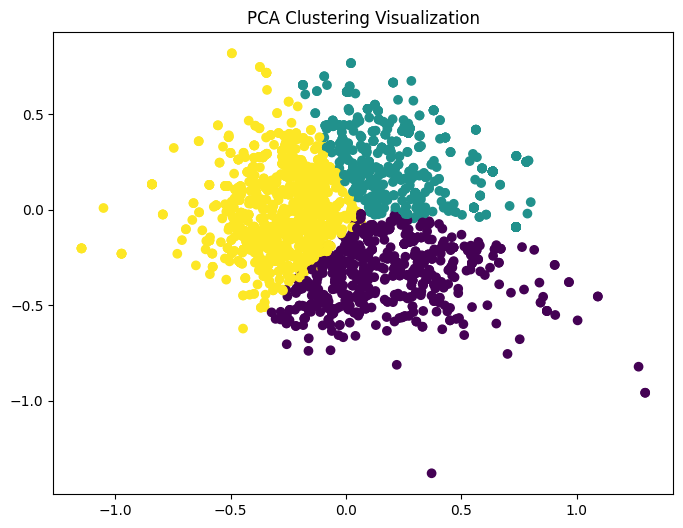

In [31]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df['Cluster'])
plt.title("PCA Clustering Visualization")
plt.show()

# Compare Clusters with Sentiment

In [32]:
pd.crosstab(df['Cluster'], df['Sentiment'])

Sentiment,Negative,Neutral,Positive
Cluster,,,
0,36,18,519
1,20,49,626
2,174,73,789


Word2Vec vs GloVe comparison

CBOW vs Skip-gram training time difference

Analogy performance

Silhouette Score interpretation

Cluster vs Sentiment relationship

Observations about semantic similarity